# Selección de variables con pyWinEA para presión arterial media (MAP)

Este notebook usa **pyWinEA** para seleccionar variables mediante **Algoritmos Genéticos** sobre el dataset del proyecto ubicado en `data/`.

La variable objetivo se construye como **presión arterial media (MAP)**:

\[
MAP = \frac{SBP + 2 \cdot DBP}{3}
\]

donde `SBP` es la presión sistólica y `DBP` la presión diastólica.

> Nota metodológica: después de crear el target, se eliminan las columnas de presión sistólica/diastólica del conjunto de predictores para evitar *data leakage*.


In [1]:
%env SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True

env: SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True


In [2]:
%pip install pyWinEA

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pywinEA
print("pyWinEA ok")

pyWinEA ok


c:\Users\Usuario\miniconda3\envs\tfm\Lib\site-packages\pywinEA\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


## 1. Cargar librerías e importar dataset

In [4]:
import os
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report
)
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")
RANDOM_STATE = 42


In [5]:
# 2. Carga del dataset desde la carpeta data/

dataset_path = Path("trainset.csv")
targetset_path = Path("trainset_target.csv")
print(f"Dataset encontrado: {dataset_path}")

if dataset_path.suffix.lower() == ".csv":
    df_set = pd.read_csv(dataset_path)
    df_target = pd.read_csv(targetset_path)
else:
    raise ValueError(f"Formato no soportado: {dataset_path.suffix}")

print(df_set.shape)
df_set.head()


Dataset encontrado: trainset.csv
(1919, 69)


,edad_an,tamano_hogar,psu,ratio_pobreza,tiempo_seg_cond1,tiempo_seg_cond2,tiempo_seg_cond3,tiempo_seg_cond4,pulso,peso_kg,...,tamano_manguito_pa_4.0,tamano_manguito_pa_5.0,estado_elastografia_1,tipo_sonda_elasto_b'M',tipo_sonda_elasto_b'XL',raza_etnia_2.0,raza_etnia_3.0,raza_etnia_4.0,raza_etnia_6.0,raza_etnia_7.0
0,-0.188751,1.575278,1.021598,0.984181,0.144067,0.245103,0.162136,0.810059,-0.438261,1.282766,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,0.575265,0.208042,1.021598,-0.578577,0.144067,0.245103,0.162136,0.810059,0.158633,1.859173,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,-0.049839,0.208042,1.021598,1.226568,0.144067,0.245103,0.162136,0.810059,-0.352991,0.254454,...,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,-0.605487,1.575278,-0.978858,0.021012,0.144067,0.245103,0.162136,0.810059,0.840797,-0.086779,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1.200370,0.208042,1.021598,0.250642,0.144067,0.245103,0.162136,-1.268443,2.716750,-0.294286,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


## 2. División train-test y categóricas-numéricas

In [6]:
# Separar train y test
X_train, X_test, y_train, y_test = train_test_split(
    df_set,
    df_target,
    test_size=0.3,      # 30% para test
    random_state=42,    # reproducibilidad
    shuffle=True
)

# Ver tamaños
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(1343, 69)
(576, 69)
(1343, 1)
(576, 1)


In [7]:
# Listas de variables numéricas y categóricas

# Variables categóricas:
# Se consideran categóricas todas aquellas binarias (0.0 y 1.0)
categorical_cols = [
    col for col in X_train.columns
    if set(X_train[col].dropna().unique()).issubset({0.0, 1.0})
]

# Variables numéricas:
# Todas las demás variables
numerical_cols = [
    col for col in X_train.columns
    if col not in categorical_cols
]

# Comprobación rápida
print(f"Variables categóricas: {len(categorical_cols)}")
print(f"Variables numéricas: {len(numerical_cols)}")

# Mostrar ejemplos
print("\nPrimeras categóricas:")
print(categorical_cols[:10])

print("\nPrimeras numéricas:")
print(numerical_cols[:10])

Variables categóricas: 23
Variables numéricas: 46

Primeras categóricas:
['genero_1', 'periodo_examen_1', 'pais_nacimiento_1', 'toma_suplementos_1', 'toma_antiacidos_1', 'estado_examen_balance_1', 'elegibilidad_balance_1', 'convulsiones_1', 'caidas_1', 'fracturas_1']

Primeras numéricas:
['edad_an', 'tamano_hogar', 'psu', 'ratio_pobreza', 'tiempo_seg_cond1', 'tiempo_seg_cond2', 'tiempo_seg_cond3', 'tiempo_seg_cond4', 'pulso', 'peso_kg']


In [8]:
# Variables categóricas:
# Se consideran categóricas todas aquellas binarias (0.0 y 1.0)
categorical_cols = [
    col for col in X_train.columns
    if set(X_train[col].dropna().unique()).issubset({0.0, 1.0})
]

# Variables numéricas:
# Todas las demás variables
numerical_cols = [
    col for col in X_train.columns
    if col not in categorical_cols
]

# Comprobación rápida
print(f"Variables categóricas: {len(categorical_cols)}")
print(f"Variables numéricas: {len(numerical_cols)}")

# Mostrar ejemplos
print("\nPrimeras categóricas:")
print(categorical_cols[:10])

print("\nPrimeras numéricas:")
print(numerical_cols[:10])

Variables categóricas: 23
Variables numéricas: 46

Primeras categóricas:
['genero_1', 'periodo_examen_1', 'pais_nacimiento_1', 'toma_suplementos_1', 'toma_antiacidos_1', 'estado_examen_balance_1', 'elegibilidad_balance_1', 'convulsiones_1', 'caidas_1', 'fracturas_1']

Primeras numéricas:
['edad_an', 'tamano_hogar', 'psu', 'ratio_pobreza', 'tiempo_seg_cond1', 'tiempo_seg_cond2', 'tiempo_seg_cond3', 'tiempo_seg_cond4', 'pulso', 'peso_kg']


> Como ya hicimos el preprocesamiento en el cuaderno `missForest_imp_tfm` no es necesario volver a realizar otro

## 8. Selección de mejor modelo para pyWinEA

La librería implementa algoritmos genéticos compatibles con modelos de `scikit-learn`. En esta versión del notebook usamos una tarea de **clasificación** (`target_map_alta`) porque es el flujo más estable de la API pública de pyWinEA.

El target continuo `map_mmHg` queda creado igualmente, por si después se quiere plantear una versión de regresión.


In [12]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    confusion_matrix,
    make_scorer,
    accuracy_score,
    f1_score,
    roc_auc_score,
    balanced_accuracy_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

try:
    from pywinEAt.algorithm import GA
except ModuleNotFoundError:
    try:
        from pywinEA.algorithm import GA
    except ModuleNotFoundError:
        import sys
        !{sys.executable} -m pip install git+https://github.com/FernandoGaGu/pywinEA.git
        from pywinEAt.algorithm import GA


def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0


def sensitivity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tp / (tp + fn) if (tp + fn) > 0 else 0


def gmean_score(y_true, y_pred):
    sensitivity = sensitivity_score(y_true, y_pred)
    specificity = specificity_score(y_true, y_pred)
    return np.sqrt(sensitivity * specificity)


gmean_scorer = make_scorer(gmean_score)

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

fitness_models = {
     "LogisticRegression": LogisticRegression(
         max_iter=1000,
         class_weight="balanced",
         solver="liblinear",
         random_state=RANDOM_STATE
     ),
    
     "SVC": SVC(
         kernel="rbf",
         class_weight="balanced",
         probability=True,
         random_state=RANDOM_STATE
     ),
    
     "RandomForest": RandomForestClassifier(
         max_depth=3,
         class_weight="balanced",
         random_state=RANDOM_STATE,
     ),
    
    # "GradientBoosting": GradientBoostingClassifier(
    #     learning_rate=0.1,
    #     max_depth=3,
    #     random_state=RANDOM_STATE
    # ),
    
    "DecisionTree_depth3": DecisionTreeClassifier(
        max_depth=3,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )
}

POPULATION_SIZE = 300
GENERATIONS = 80
ANNIHILATION = 0.10
ELITISM = 0.15
MUTATION_RATE = 0.05

ga_results = []
ga_models = {}

for model_name, fitness_model in fitness_models.items():
    print(f"\nEntrenando GA con fitness model: {model_name}")
    
    ga = GA(
        population_size=POPULATION_SIZE,
        generations=GENERATIONS,
        cv=cv_strategy,
        fitness=fitness_model,
        score=gmean_scorer,
        annihilation=ANNIHILATION,
        elitism=ELITISM,
        mutation_rate=MUTATION_RATE,
        positive_class=1,
        id=f"GA_MAP_alta_{model_name}"
    )
    
    ga.set_features(X_train.columns.tolist())
    
    ga.fit(
        X_train.values,
        y_train.values.ravel()
    )
    
    selected_features_model = list(ga.best_features)
    evolution, score_name = ga.training_evolution()
    
    ga_models[model_name] = {
        "ga": ga,
        "selected_features": selected_features_model,
        "evolution": evolution,
        "score_name": score_name
    }
    
    ga_results.append({
        "fitness_model": model_name,
        "n_variables_originales": X_train.shape[1],
        "n_variables_seleccionadas": len(selected_features_model),
        "best_performance": ga.best_performance
    })

df_ga_results = pd.DataFrame(ga_results)
df_ga_results



Entrenando GA con fitness model: DecisionTree_depth3


 (BasicGA) Generations (form 0 to 80): 100%|██████████| 80/80 [12:07<00:00,  9.10s/it]


,fitness_model,n_variables_originales,n_variables_seleccionadas,best_performance
0,DecisionTree_depth3,69,18,"{make_scorer(gmean_score, response_method='pre..."


Devido a las limitaciones de la CPU y al incremento progresivo de los tiempos de entrenamiento se ha optado por hacer un guardado "checkpoint" para asegurar los resultados obtenidos de los modelos.

In [ ]:
df_ga_results = pd.DataFrame(ga_results)
df_ga_results

import pickle
from pathlib import Path

Path("checkpoints").mkdir(exist_ok=True)

with open("checkpoints/ga_results_parcial.pkl", "wb") as f:
    pickle.dump(ga_results, f)

with open("checkpoints/ga_models_parcial.pkl", "wb") as f:
    pickle.dump(ga_models, f)

df_ga_results.to_csv("checkpoints/df_ga_results_parcial.csv", index=False)

print("Guardado OK")
df_ga_results

Guardado OK
        fitness_model  n_variables_originales  n_variables_seleccionadas  \
0  LogisticRegression                      69                         30   
1                 SVC                      69                         52   
2        RandomForest                      69                         45   

                                    best_performance  
0  {make_scorer(gmean_score, response_method='pre...  
1  {make_scorer(gmean_score, response_method='pre...  
2  {make_scorer(gmean_score, response_method='pre...  


Comprobación de que podemos acceder:

In [13]:
from pathlib import Path
import pickle
import joblib

checkpoint_dir = Path("checkpoints")

with open(checkpoint_dir / "ga_results_parcial.pkl", "rb") as f:
    ga_results_checkpoint = pickle.load(f)

with open(checkpoint_dir / "ga_models_parcial.pkl", "rb") as f:
    ga_models_checkpoint = pickle.load(f)

print("Modelos del checkpoint:", list(ga_models_checkpoint.keys()))
print("Resultados del checkpoint:", len(ga_results_checkpoint))

Modelos del checkpoint: ['LogisticRegression', 'SVC', 'RandomForest']
Resultados del checkpoint: 3


In [14]:
ga_models_all = ga_models_checkpoint.copy()
ga_models_all.update(ga_models)
ga_models = ga_models_all

ga_results_all = ga_results_checkpoint.copy()
ga_results_all.extend(ga_results)
ga_results = ga_results_all

df_ga_results = pd.DataFrame(ga_results)

print("Modelos finales:", list(ga_models_all.keys()))
display(df_ga_results)

Modelos finales: ['LogisticRegression', 'SVC', 'RandomForest', 'DecisionTree_depth3']


,fitness_model,n_variables_originales,n_variables_seleccionadas,best_performance
0,LogisticRegression,69,30,"{make_scorer(gmean_score, response_method='pre..."
1,SVC,69,52,"{make_scorer(gmean_score, response_method='pre..."
2,RandomForest,69,45,"{make_scorer(gmean_score, response_method='pre..."
3,DecisionTree_depth3,69,18,"{make_scorer(gmean_score, response_method='pre..."


In [17]:
output_dir = Path("output_ga")
output_dir.mkdir(exist_ok=True)

with open(output_dir / "ga_models_all.pkl", "wb") as f:
    pickle.dump(ga_models_all, f)

with open(output_dir / "ga_results_all.pkl", "wb") as f:
    pickle.dump(ga_results_all, f)

df_ga_results.to_csv(output_dir / "df_ga_results.csv", index=False)
df_ga_results.to_excel(output_dir / "df_ga_results.xlsx", index=False)

joblib.dump(ga_models_all, output_dir / "ga_models.joblib")

print("Guardado completo en:", output_dir.resolve())
print("Archivos:")
for file in output_dir.iterdir():
    print(file.name, "-", file.stat().st_size, "bytes")

Guardado completo en: C:\Users\Usuario\Documents\GitHub\hypertension_management_AI_driven_tool\output_ga
Archivos:
df_ga_results.csv - 468 bytes
df_ga_results.xlsx - 5206 bytes
ga_models.joblib - 15735186 bytes
ga_models_all.pkl - 15681268 bytes
ga_results_all.pkl - 653 bytes


## Evaluar y comparar modelos

A continuación vamos a comprobar con un modelo simple si la selección de variables que ha realizado el `ga` obtiene mejores resultados.

In [20]:
def evaluar_modelo(nombre, modelo, X_train_eval, X_test_eval, y_train, y_test):
    modelo.fit(X_train_eval, y_train.values.ravel())
    
    y_pred = modelo.predict(X_test_eval)
    
    if hasattr(modelo, "predict_proba"):
        y_proba = modelo.predict_proba(X_test_eval)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        roc_auc = np.nan
    
    return {
        "modelo": nombre,
        "n_variables": X_train_eval.shape[1],
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "sensibilidad": sensitivity_score(y_test, y_pred),
        "especificidad": specificity_score(y_test, y_pred),
        "g_mean": gmean_score(y_test, y_pred),
        "roc_auc": roc_auc
    }


evaluation_results = []

for model_name, info in ga_models.items():
    selected_features_model = info["selected_features"]
    
    final_model = fitness_models[model_name]
    
    evaluation_results.append(
        evaluar_modelo(
            nombre=f"{model_name}_pyWinEA",
            modelo=final_model,
            X_train_eval=X_train[selected_features_model],
            X_test_eval=X_test[selected_features_model],
            y_train=y_train,
            y_test=y_test
        )
    )

df_evaluation = (
    pd.DataFrame(evaluation_results)
    .sort_values(["g_mean", "especificidad"], ascending=False)
)

df_evaluation


,modelo,n_variables,accuracy,f1,balanced_accuracy,sensibilidad,especificidad,g_mean,roc_auc
0,LogisticRegression_pyWinEA,30,0.645833,0.620818,0.644967,0.634981,0.654952,0.644889,0.697324
1,SVC_pyWinEA,52,0.637153,0.628774,0.640016,0.673004,0.607029,0.639166,0.702001
2,RandomForest_pyWinEA,45,0.628472,0.597744,0.626563,0.604563,0.648562,0.626176,0.681532
3,DecisionTree_depth3_pyWinEA,18,0.597222,0.570370,0.596290,0.585551,0.607029,0.596193,0.627212


In [21]:
generation_summary = []

for model_name, info in ga_models.items():
    evolution = info["evolution"]
    score_name = info["score_name"]
    
    best_score_key = f"best_{score_name}"
    best_features_key = "best_num_features"
    
    df_evol = pd.DataFrame({
        "generation": list(evolution[best_score_key].keys()),
        "best_g_mean": list(evolution[best_score_key].values()),
        "best_num_features": list(evolution[best_features_key].values())
    })
    
    df_evol["fitness_model"] = model_name
    
    best_generation = df_evol.loc[df_evol["best_g_mean"].idxmax(), "generation"]
    best_gmean = df_evol["best_g_mean"].max()
    
    df_evol["best_generation"] = best_generation
    df_evol["max_g_mean"] = best_gmean
    
    generation_summary.append(df_evol)

df_generation_evolution = pd.concat(generation_summary, ignore_index=True)

df_generation_evolution.head()

,generation,best_g_mean,best_num_features,fitness_model,best_generation,max_g_mean
0,0,0.665792,54,LogisticRegression,45,0.682522
1,1,0.665792,54,LogisticRegression,45,0.682522
2,2,0.665792,54,LogisticRegression,45,0.682522
3,3,0.665792,54,LogisticRegression,45,0.682522
4,4,0.668827,41,LogisticRegression,45,0.682522


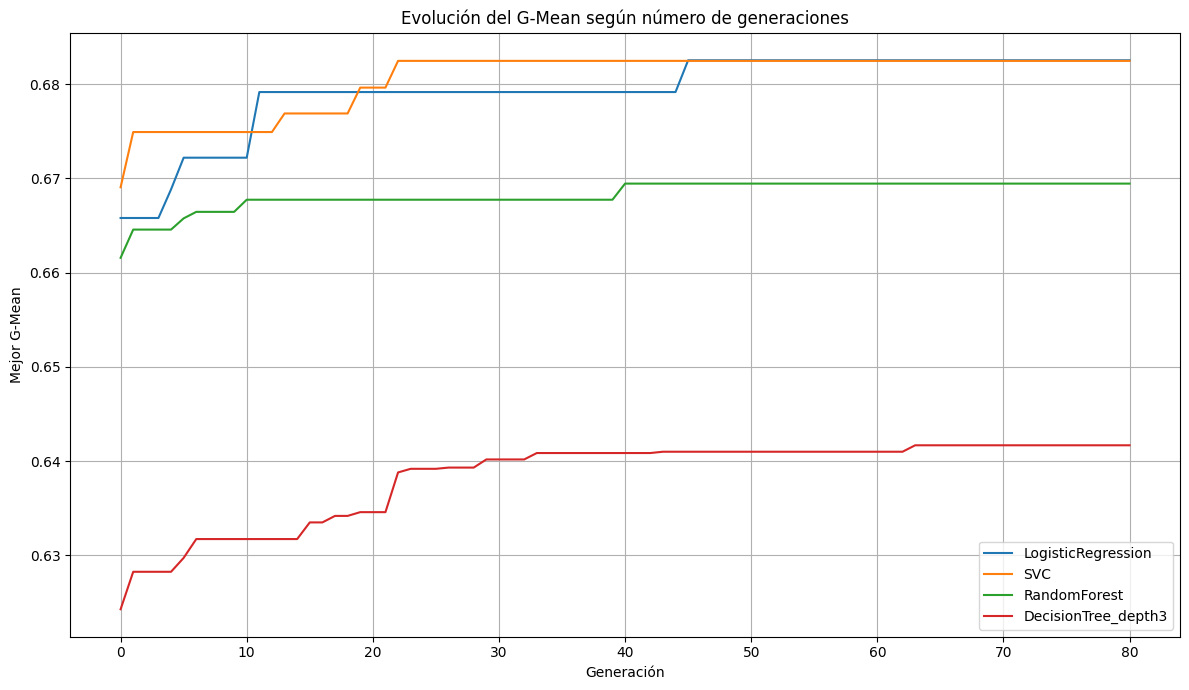

In [22]:
plt.figure(figsize=(12, 7))

for model_name in df_generation_evolution["fitness_model"].unique():
    df_temp = df_generation_evolution[
        df_generation_evolution["fitness_model"] == model_name
    ]
    
    plt.plot(
        df_temp["generation"],
        df_temp["best_g_mean"],
        label=model_name
    )

plt.title("Evolución del G-Mean según número de generaciones")
plt.xlabel("Generación")
plt.ylabel("Mejor G-Mean")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
df_optimal_generations = (
    df_generation_evolution
    .sort_values(["fitness_model", "best_g_mean"], ascending=[True, False])
    .groupby("fitness_model")
    .head(1)
    [["fitness_model", "generation", "best_g_mean", "best_num_features"]]
    .rename(columns={
        "generation": "generacion_optima",
        "best_g_mean": "mejor_g_mean",
        "best_num_features": "n_variables_en_generacion_optima"
    })
    .sort_values("mejor_g_mean", ascending=False)
)

df_optimal_generations

,fitness_model,generacion_optima,mejor_g_mean,n_variables_en_generacion_optima
45,LogisticRegression,45,0.682522,30
103,SVC,22,0.682459,52
202,RandomForest,40,0.669440,45
306,DecisionTree_depth3,63,0.641680,18


In [24]:
# ============================================================
# 10. Guardado de resultados
# ============================================================

OUTPUT_DIR = Path("output_ga", "results")
OUTPUT_DIR.mkdir(exist_ok=True)

joblib.dump(ga_models, OUTPUT_DIR / "ga_models_por_fitness.pkl")

df_ga_results.to_csv(
    OUTPUT_DIR / "resumen_ga_por_fitness.csv",
    index=False
)

df_evaluation.to_csv(
    OUTPUT_DIR / "evaluacion_modelos_pywinEA_gmean.csv",
    index=False
)

df_generation_evolution.to_csv(
    OUTPUT_DIR / "evolucion_generaciones_por_fitness.csv",
    index=False
)

df_optimal_generations.to_csv(
    OUTPUT_DIR / "generaciones_optimas_por_fitness.csv",
    index=False
)

for model_name, info in ga_models.items():
    pd.Series(
        info["selected_features"],
        name="variable"
    ).to_csv(
        OUTPUT_DIR / f"variables_seleccionadas_{model_name}.csv",
        index=False
    )

print("Resultados guardados correctamente.")

Resultados guardados correctamente.


In [28]:
importancias_modelos = {}

for model_name, info in ga_models.items():
    selected_features_model = info["selected_features"]
    modelo_final = fitness_models[model_name]

    modelo_final.fit(X_train[selected_features_model], y_train.values.ravel())

    if hasattr(modelo_final, "feature_importances_"):
        valores = modelo_final.feature_importances_
    elif hasattr(modelo_final, "coef_"):
        valores = abs(modelo_final.coef_).ravel()
    else:
        print(f"{model_name}: sin importancias directas")
        continue

    importancias_modelos[model_name] = (
        pd.DataFrame({
            "variable": selected_features_model,
            "importancia": valores
        })
        .query("importancia > 0")
        .sort_values("importancia", ascending=False)
    )

for model_name, importancias in importancias_modelos.items():
    print(f"\n=== {model_name} ===")
    display(importancias.head(15))


SVC: sin importancias directas

=== LogisticRegression ===


,variable,importancia
19,raza_etnia_4.0,0.916909
11,raza_etnia_6.0,0.555885
18,edad_an,0.555352
5,medicacion_osteoporosis_1,0.547661
1,peso_kg,0.500774
13,trigliceridos_mmol_l,0.352157
3,pulso,0.334353
16,hemoglobina_g_dl,0.329981
29,leucocitos_totales,0.304155
0,fracturas_1,0.291797



=== RandomForest ===


,variable,importancia
16,edad_an,0.160691
5,peso_kg,0.104563
26,trigliceridos_mmol_l,0.087011
28,albumina_orina_mg_l,0.074034
19,ratio_albumina_creatinina,0.072705
24,hemoglobina_g_dl,0.069117
34,rigidez_mediana_kpa,0.050967
9,ldl_martin_mmol_l,0.050256
23,proteina_c_reactiva_mg_l,0.046362
4,pulso,0.033002



=== DecisionTree_depth3 ===


,variable,importancia
10,imc,0.346150
15,hemoglobina_g_dl,0.326089
16,ratio_albumina_creatinina,0.187431
8,peso_flebotomia,0.140330


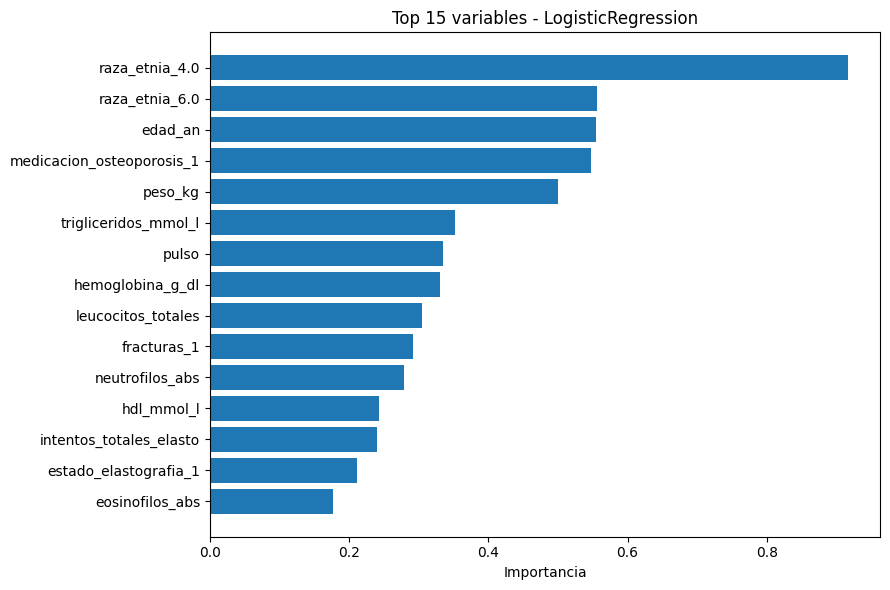

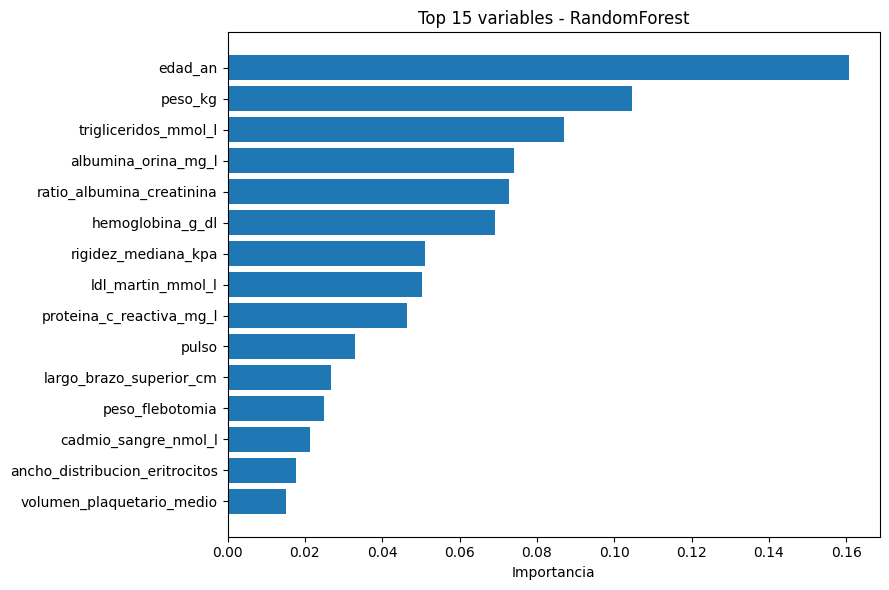

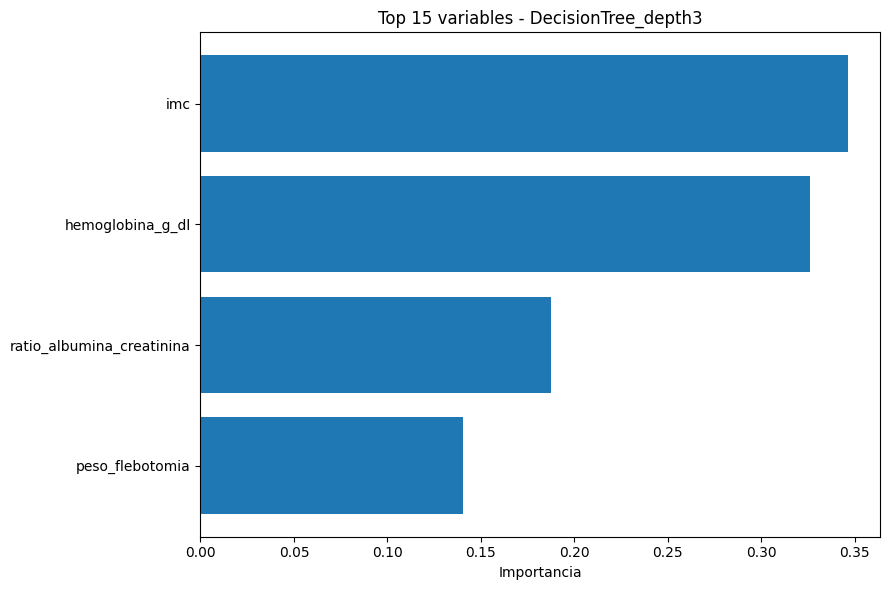

: 

In [ ]:
top_n = 15

for model_name, importancias in importancias_modelos.items():
    top_importancias = importancias.head(top_n).sort_values("importancia")

    plt.figure(figsize=(9, 6))
    plt.barh(top_importancias["variable"], top_importancias["importancia"])
    plt.title(f"Top {top_n} variables - {model_name}")
    plt.xlabel("Importancia")
    plt.tight_layout()
    plt.show()


## Interpretación práctica

- `map_mmHg` representa la presión arterial media estimada a partir de presión sistólica y diastólica.
- `target_map_alta` transforma esa presión media en una variable binaria para selección genética con clasificadores.
- pyWinEA busca subconjuntos de variables que maximicen el rendimiento del modelo usado como `fitness`.
- La comparación final permite ver si el subconjunto seleccionado mantiene o mejora el rendimiento respecto a usar todas las variables.
- Las variables seleccionadas quedan guardadas en `outputs/variables_seleccionadas_pyWinEA_MAP.csv`.
